In [2]:
import json
from pathlib import Path

import h5py
import numpy as np

# --- deny-list of grid points with no spectrum --------------------------------
# species stores an all-zero spectrum for any grid point whose model file is
# absent and that linear interpolation could not recover. That is the
# "Could not interpolate N grid points so storing zeros instead" warning that
# add_model prints. Sampling one of those points gives a band flux of exactly
# 0.0, and get_magnitude then dies inside math.log10(0.0) with
# "math domain error". get_flux does not raise on them, it just hands back 0.0,
# so they quietly poison the flux columns as well.
#
# For Elf Owl every missing point sits at logg = 3.0: the distribution ships
# only 12 logg_3.00 spectra (all feh=1.0, co=0.458, logkzz=8.0) out of 1440,
# and logg=3.0 is on the edge of the axis so griddata could not extrapolate
# the rest. Nothing at logg >= 3.25 is missing.

DENY_PATH = Path("missing_grid_points.json")


def scan_missing_grid_points(tag, db_path="species_database.hdf5"):
    """Find every grid cell of `tag` that holds an all-zero spectrum.

    Returns (params, axes, mask), where `mask` is a boolean array over the grid
    axes that is True wherever the spectrum is missing.
    """
    with h5py.File(db_path, "r") as hdf:
        group = hdf[f"models/{tag}"]
        params = [group.attrs[f"parameter{i}"] for i in range(group.attrs["n_param"])]
        axes = {param: group[param][:] for param in params}

        flux = group["flux"]
        mask = np.zeros(flux.shape[: len(params)], dtype=bool)

        # One teff slice at a time (~68 MB) instead of the whole ~818 MB array.
        for i in range(flux.shape[0]):
            mask[i] = ~np.any(flux[i] != 0.0, axis=-1)

    return params, axes, mask


def denied_axis_values(params, axes, mask):
    """Smallest set of axis values to drop so no missing cell stays reachable.

    Greedy set cover: repeatedly drop whichever (parameter, value) accounts for
    the most still-missing cells. Because the sampler draws each axis
    independently, removing these values from the pool makes every possible
    draw valid by construction.
    """
    remaining = np.argwhere(mask)
    dropped = {}

    while len(remaining):
        best_axis, best_idx, best_count = None, None, -1

        for axis, param in enumerate(params):
            for idx in np.unique(remaining[:, axis]):
                count = int(np.count_nonzero(remaining[:, axis] == idx))
                if count > best_count:
                    best_axis, best_idx, best_count = axis, idx, count

        best_param = params[best_axis]
        dropped.setdefault(best_param, []).append(float(axes[best_param][best_idx]))
        remaining = remaining[remaining[:, best_axis] != best_idx]

    return dropped


def load_deny_list(tags, db_path="species_database.hdf5", path=DENY_PATH, rebuild=False):
    """Load the cached deny-list, scanning the database the first time."""
    if path.exists() and not rebuild:
        return json.loads(path.read_text())

    deny = {}

    for tag in tags:
        params, axes, mask = scan_missing_grid_points(tag, db_path)

        combos = [
            [float(axes[param][i]) for param, i in zip(params, idx)]
            for idx in np.argwhere(mask)
        ]

        deny[tag] = {
            "params": params,
            "denied_axis_values": denied_axis_values(params, axes, mask),
            "combos": combos,
        }

        print(
            f"{tag}: {len(combos)} missing grid points"
            f" -> drop {deny[tag]['denied_axis_values']}"
        )

    path.write_text(json.dumps(deny, indent=1))

    return deny


species

Version: 0.10.4
Working folder: /Users/mitchellfoote/Documents/Source/research/dwarfhunt/michelson-repro

Configuration file: /Users/mitchellfoote/Documents/Source/research/dwarfhunt/michelson-repro/species_config.ini
Database file: species_database.hdf5
Data folder: data

Configuration settings:
   - Database: species_database.hdf5
   - Data folder: data
   - Magnitude of Vega: 0.03

Multiprocessing: mpi4py not installed
models loaded
sonora-elfowl-t: dropping logg = [np.float64(3.0)] (no spectra)
model array created
sonora-elfowl-y: dropping logg = [np.float64(3.0)] (no spectra)
model_y array created
flux models loaded
staring with planet 0 with parameters: {'teff': 650.0, 'logg': 5.25, 'feh': 0.5, 'c_o_ratio': 1.145, 'log_kzz': 9.0, 'radius': 0.8557676089208651, 'distance': 10.0}
planet magnitude found 0
staring with planet 1 with parameters: {'teff': 1100.0, 'logg': 5.5, 'feh': 0.7, 'c_o_ratio': 0.458, 'log_kzz': 9.0, 'radius': 1.26230201307308, 'distance': 10.0}
planet ma

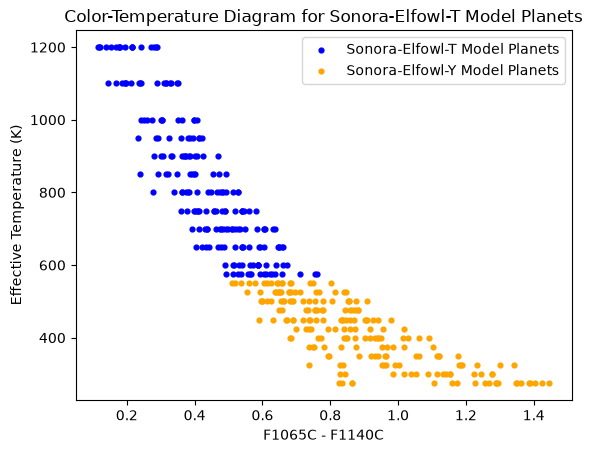

In [2]:
from contextlib import contextmanager
from itertools import product

import numpy as np
from species.read.read_model import ReadModel
import species.read.read_model as read_model_module
import matplotlib.pyplot as plt
from dwarfhunt import planets as helpers
import dwarfhunt

db = dwarfhunt.init(force_species_init=True)

#db.add_model('sonora-elfowl-t', wavel_range=(.61, 14.9), wavel_sampling=2000.0)
#db.add_model('sonora-elfowl-y', wavel_range=(.61, 14.9), wavel_sampling=2000.0)
# db.add_filter('JWST/MIRI.F1065C')
# db.add_filter('JWST/MIRI.F1140C')
# db.add_filter('JWST/MIRI.F1550C')

model = ReadModel('sonora-elfowl-t', wavel_range=(.61, 14.9))
model_y = ReadModel('sonora-elfowl-y', wavel_range=(.61, 14.9))

print('models loaded')

# grid points that have no spectrum behind them, see the cell above


model_planet_array = helpers.generate_planet_arrays(model, radius_range=(0.6, 1.3), distance=10, num_samples=200, deny=helpers.deny_list())
print('model array created')
model_y_planet_array = helpers.generate_planet_arrays(model_y, radius_range=(0.6, 1.3), distance=10, num_samples=200, deny=helpers.deny_list())
print('model_y array created')
#using np arrays, use the update_planet_flux_and_magnitude function to add flux and magnitude values to the model_planet_array
model_planet_array_with_flux = helpers.update_planet_flux_and_magnitude(model, model_planet_array)
model_y_planet_array_with_flux = helpers.update_planet_flux_and_magnitude(model_y, model_y_planet_array)
fig, ax = plt.subplots()

ax.scatter(model_planet_array_with_flux['F1065C - F1140C'], model_planet_array_with_flux['teff'],
           s=12, label='Sonora-Elfowl-T Model Planets', color="blue")
ax.scatter(model_y_planet_array_with_flux['F1065C - F1140C'], model_y_planet_array_with_flux['teff'],
           s=12, label='Sonora-Elfowl-Y Model Planets', color='orange')
ax.set_xlabel('F1065C - F1140C')
ax.set_ylabel('Effective Temperature (K)')
ax.set_title('Color-Temperature Diagram for Sonora-Elfowl-T Model Planets')
ax.legend()
fig.savefig('color_temperature_diagram.png', dpi=300)
plt.show()
